In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os, shutil, pathlib, json, random
from datetime import datetime

print("TensorFlow version :", tf.__version__)
print("GPU tersedia       :", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version : 2.20.0
GPU tersedia       : True


In [3]:
from google.colab import userdata
import os, json

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({
        "username": userdata.get('KAGGLE_USERNAME'),
        "key": userdata.get('KAGGLE_KEY')
    }, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✓ Kaggle API siap")

print("\nDownloading PlantVillage (~1.5GB)...")
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip -q -o plantvillage-dataset.zip -d plantvillage_raw
print("✓ Selesai download & extract")

✓ Kaggle API siap

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:21<00:00, 101MB/s]

✓ Selesai download & extract


In [4]:
raw_dir = pathlib.Path('plantvillage_raw')

print("=== Folder di dalam dataset ===\n")
all_folders = []
for item in sorted(raw_dir.rglob('*')):
    if item.is_dir():
        count = len(list(item.glob('*.jpg'))) + len(list(item.glob('*.png')))
        if count > 0:
            all_folders.append((item, count))
            print(f"  {item.name:<50s}: {count} gambar")

print(f"\nTotal folder dengan gambar: {len(all_folders)}")
print("\n⚠️  PASTE OUTPUT INI ke chat sebelum lanjut Cell 4!")

=== Folder di dalam dataset ===

  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 67 gambar
  Corn_(maize)___Northern_Leaf_Blight               : 115 gambar
  Corn_(maize)___healthy                            : 1141 gambar
  Pepper,_bell___healthy                            : 2 gambar
  Squash___Powdery_mildew                           : 22 gambar
  Strawberry___Leaf_scorch                          : 1 gambar
  Tomato___Late_blight                              : 152 gambar
  Tomato___healthy                                  : 1 gambar
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 67 gambar
  Corn_(maize)___Northern_Leaf_Blight               : 115 gambar
  Corn_(maize)___healthy                            : 1141 gambar
  Pepper,_bell___healthy                            : 2 gambar
  Squash___Powdery_mildew                           : 22 gambar
  Strawberry___Leaf_scorch                          : 1 gambar
  Tomato___Late_blight                              : 152 gambar
  To

In [5]:
TARGET_CLASSES = {
    'Tomato___healthy'                              : 'Tomat_Sehat',
    'Tomato___Early_blight'                         : 'Tomat_Early_Blight',
    'Tomato___Late_blight'                          : 'Tomat_Late_Blight',
    'Tomato___Leaf_Mold'                            : 'Tomat_Leaf_Mold',
    'Tomato___Bacterial_spot'                       : 'Tomat_Bacterial_Spot',
}

MIN_IMAGES = 500

raw_dir     = pathlib.Path('plantvillage_raw')
working_dir = pathlib.Path('dataset_plantvillage')

if working_dir.exists():
    shutil.rmtree(working_dir)
working_dir.mkdir()

print("=== Tahap 1: Scan semua kelas ===\n")

class_sources = {}
for folder_name, label in TARGET_CLASSES.items():
    matches = []
    for item in raw_dir.rglob('*'):
        if item.is_dir() and item.name == folder_name:
            count = len(list(item.glob('*.jpg'))) + len(list(item.glob('*.png')))
            if count >= MIN_IMAGES:
                matches.append((item, count))

    if not matches:
        print(f"❌ Tidak ditemukan: {folder_name}")
        continue

    best_match = max(matches, key=lambda x: x[1])
    src, count = best_match
    class_sources[label] = (src, count)
    print(f"  {label:<30s}: {count} gambar ditemukan")

MAX_PER_CLASS = min(count for _, count in class_sources.values())
print(f"\n→ Semua kelas akan dibatasi ke {MAX_PER_CLASS} gambar (jumlah terkecil)\n")

print("=== Tahap 2: Menyalin dataset (balanced) ===\n")

for label, (src, total_count) in class_sources.items():
    dst = working_dir / label
    dst.mkdir()

    all_images = list(src.glob('*.jpg')) + list(src.glob('*.png'))

    random.seed(42)
    selected = random.sample(all_images, MAX_PER_CLASS)

    for img_path in selected:
        shutil.copy(str(img_path), str(dst / img_path.name))

    print(f"✓ {label:<30s}: {MAX_PER_CLASS} gambar disalin (dari {total_count})")

print("\n=== Verifikasi ===")
total = 0
for folder in sorted(working_dir.iterdir()):
    if folder.is_dir():
        count = len(list(folder.glob('*.jpg'))) + \
                len(list(folder.glob('*.png')))
        total += count
        print(f"  {folder.name:<30s}: {count} gambar")
print(f"\n  Total: {total} gambar dari {len(list(working_dir.iterdir()))} kelas")
print(f"  Setiap kelas: {MAX_PER_CLASS} gambar ✓")

=== Tahap 1: Scan semua kelas ===

  Tomat_Sehat                   : 1591 gambar ditemukan
  Tomat_Early_Blight            : 1000 gambar ditemukan
  Tomat_Late_Blight             : 1909 gambar ditemukan
  Tomat_Leaf_Mold               : 952 gambar ditemukan
  Tomat_Bacterial_Spot          : 2127 gambar ditemukan

→ Semua kelas akan dibatasi ke 952 gambar (jumlah terkecil)

=== Tahap 2: Menyalin dataset (balanced) ===

✓ Tomat_Sehat                   : 952 gambar disalin (dari 1591)
✓ Tomat_Early_Blight            : 952 gambar disalin (dari 1000)
✓ Tomat_Late_Blight             : 952 gambar disalin (dari 1909)
✓ Tomat_Leaf_Mold               : 952 gambar disalin (dari 952)
✓ Tomat_Bacterial_Spot          : 952 gambar disalin (dari 2127)

=== Verifikasi ===
  Tomat_Bacterial_Spot          : 952 gambar
  Tomat_Early_Blight            : 952 gambar
  Tomat_Late_Blight             : 952 gambar
  Tomat_Leaf_Mold               : 952 gambar
  Tomat_Sehat                   : 952 gambar

  Total:

In [6]:
class_names_preview = sorted([d.name for d in working_dir.iterdir() if d.is_dir()])
num_classes = len(class_names_preview)

fig, axes = plt.subplots(num_classes, 5, figsize=(18, num_classes * 3.5))
if num_classes == 1:
    axes = axes.reshape(1, -1)

for row, class_name in enumerate(class_names_preview):
    folder = working_dir / class_name
    images = list(folder.glob('*.jpg')) + list(folder.glob('*.png'))

    indices = np.linspace(0, len(images)-1, 5, dtype=int)
    samples = [images[i] for i in indices]

    for col, img_path in enumerate(samples):
        img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(
                class_name.replace('Tomat_', ''),
                fontsize=11, rotation=0,
                labelpad=100, ha='right', va='center'
            )

plt.suptitle('Sample Dataset — Penyakit Daun Tomat (5 per kelas)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('sample_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [7]:
IMG_SIZE   = 224
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    working_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    working_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names = train_ds.class_names
num_classes = len(class_names)

train_size = sum(1 for _ in train_ds.unbatch())
val_size   = sum(1 for _ in val_ds.unbatch())

print(f"✓ Dataset siap")
print(f"  Kelas          : {class_names}")
print(f"  Training data  : {train_size} gambar")
print(f"  Validation data: {val_size} gambar")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(train_size, reshuffle_each_iteration=True).cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

Found 4760 files belonging to 5 classes.
Using 3808 files for training.
Found 4760 files belonging to 5 classes.
Using 952 files for validation.
✓ Dataset siap
  Kelas          : ['Tomat_Bacterial_Spot', 'Tomat_Early_Blight', 'Tomat_Late_Blight', 'Tomat_Leaf_Mold', 'Tomat_Sehat']
  Training data  : 3808 gambar
  Validation data: 952 gambar


In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
], name="augmentation")

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.build(input_shape=(None, IMG_SIZE, IMG_SIZE, 3))
print(f"✓ Model siap")
print(f"  Kelas          : {num_classes}")
print(f"  Total parameter: {model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ Model siap
  Kelas          : 5
  Total parameter: 2,422,597


In [9]:
EPOCHS = 20

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1,
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1,
        min_lr=1e-6
    )
]

print("Memulai training...\n")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

best_acc = max(history.history['val_accuracy']) * 100
print(f"\n{'='*50}")
print(f"✓ TRAINING SELESAI")
print(f"{'='*50}")
print(f"Best val accuracy: {best_acc:.2f}%")

if best_acc >= 95:
    print("🏆 EXCELLENT!")
elif best_acc >= 90:
    print("✅ BAGUS!")
elif best_acc >= 80:
    print("⚠️  Cukup, bisa fine-tuning")
else:
    print("❌ Perlu investigasi")

Memulai training...

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 25s 83ms/step - accuracy: 0.6681 - loss: 0.8694 - val_accuracy: 0.8771 - val_loss: 0.3916 - learning_rate: 0.0010
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.8038 - loss: 0.5249 - val_accuracy: 0.8918 - val_loss: 0.3315 - learning_rate: 0.0010
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.8251 - loss: 0.4679 - val_accuracy: 0.8887 - val_loss: 0.3170 - learning_rate: 0.0010
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.8461 - loss: 0.4214 - val_accuracy: 0.9023 - val_loss: 0.2940 - learning_rate: 0.0010
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.8480 - loss: 0.4076 - val_accuracy: 0.8792 - val_loss: 0.3158 - learning_rate: 0.0010
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.8642 - loss: 0.3747 - val_accuracy: 0.8897 - val_loss: 0.2941 - learning_rate: 0.0010
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accu

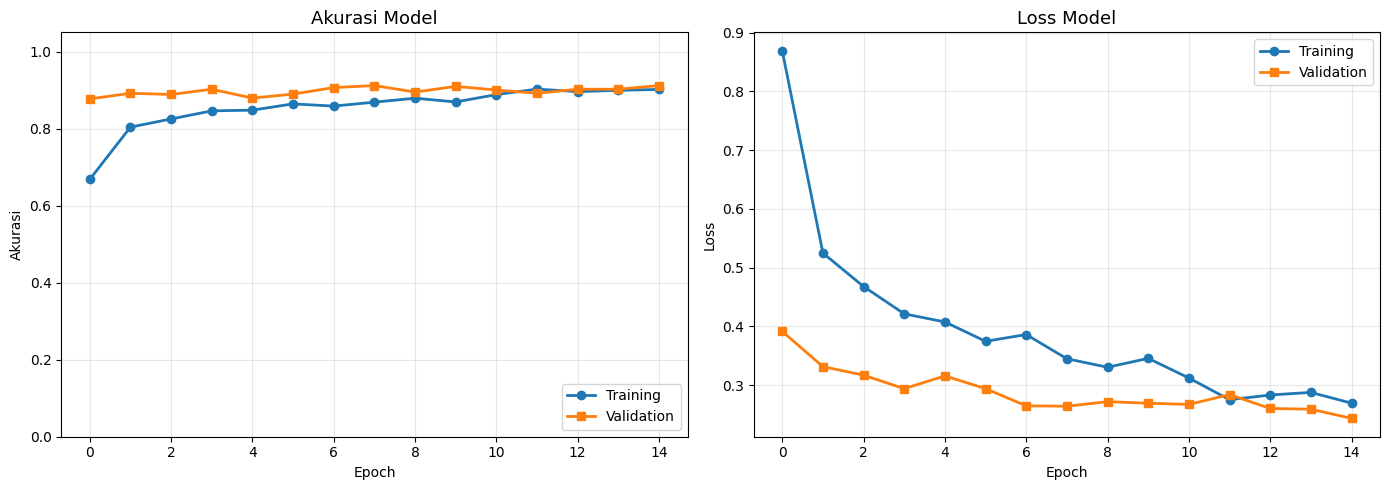

Gap training-validation: -0.9%
✅ Tidak overfitting


In [10]:
acc       = history.history['accuracy']
val_acc   = history.history['val_accuracy']
loss      = history.history['loss']
val_loss  = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc,     label='Training',   marker='o', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation', marker='s', linewidth=2)
plt.title('Akurasi Model', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.ylim([0, 1.05])

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss,     label='Training',   marker='o', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation', marker='s', linewidth=2)
plt.title('Loss Model', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

gap = max(acc) - max(val_acc)
print(f"Gap training-validation: {gap*100:.1f}%")
if gap < 0.05:
    print("✅ Tidak overfitting")
elif gap < 0.15:
    print("✅ Gap kecil, normal")
else:
    print("⚠️  Ada tanda overfitting")

AKURASI PER KELAS

Kelas                          Akurasi      n    
--------------------------------------------------
  Tomat_Bacterial_Spot          96.0%      173
  Tomat_Early_Blight            77.4%      186
  Tomat_Late_Blight             91.3%      206
  Tomat_Leaf_Mold               95.1%      203
  Tomat_Sehat                   96.2%      184
--------------------------------------------------
  OVERALL                       91.2%


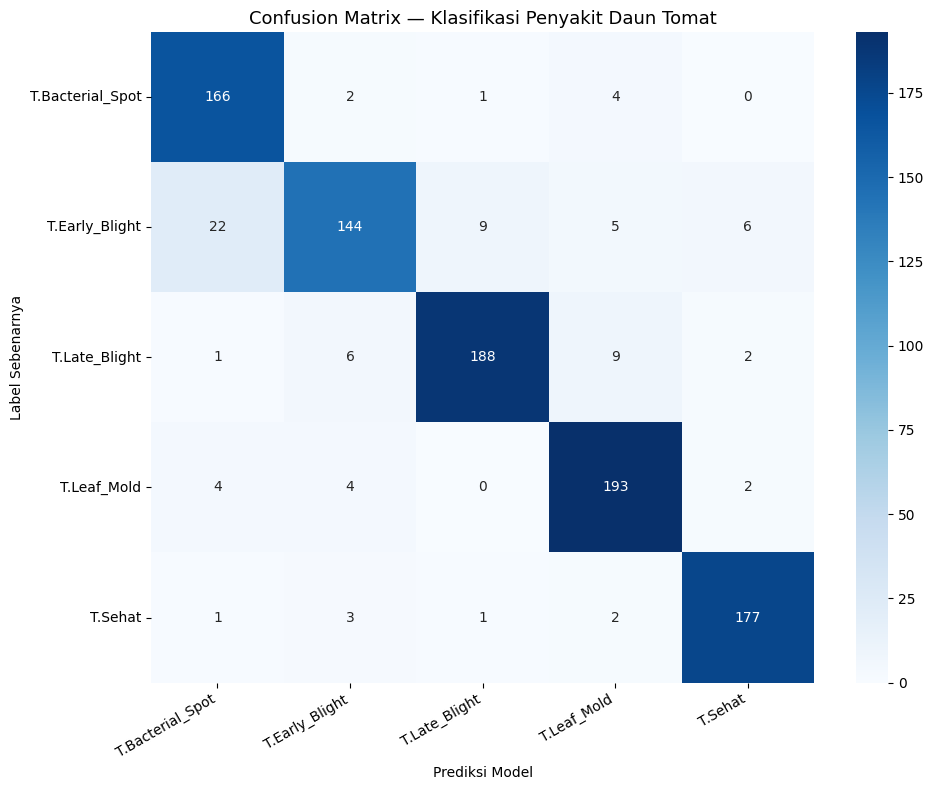


=== Classification Report ===
                      precision    recall  f1-score   support

Tomat_Bacterial_Spot       0.86      0.96      0.90       173
  Tomat_Early_Blight       0.91      0.77      0.83       186
   Tomat_Late_Blight       0.94      0.91      0.93       206
     Tomat_Leaf_Mold       0.91      0.95      0.93       203
         Tomat_Sehat       0.95      0.96      0.95       184

            accuracy                           0.91       952
           macro avg       0.91      0.91      0.91       952
        weighted avg       0.91      0.91      0.91       952



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

all_true = []
all_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    all_true.extend(labels.numpy())
    all_pred.extend(np.argmax(preds, axis=1))

all_true = np.array(all_true)
all_pred = np.array(all_pred)

print("=" * 65)
print("AKURASI PER KELAS")
print("=" * 65)
print(f"\n{'Kelas':<30s} {'Akurasi':<12s} {'n':<5s}")
print("-" * 50)
for i, name in enumerate(class_names):
    mask = all_true == i
    if mask.sum() > 0:
        acc_cls = (all_pred[mask] == i).mean() * 100
        print(f"  {name:<28s} {acc_cls:5.1f}%      {mask.sum()}")

overall = (all_pred == all_true).mean() * 100
print("-" * 50)
print(f"  {'OVERALL':<28s} {overall:5.1f}%")

short_labels = [n.replace('Tomat_', 'T.').replace('Tomato_', 'T.') for n in class_names]

cm = confusion_matrix(all_true, all_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_labels, yticklabels=short_labels)
plt.title('Confusion Matrix — Klasifikasi Penyakit Daun Tomat', fontsize=13)
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Classification Report ===")
print(classification_report(all_true, all_pred, target_names=class_names))

=== Contoh Prediksi Model ===



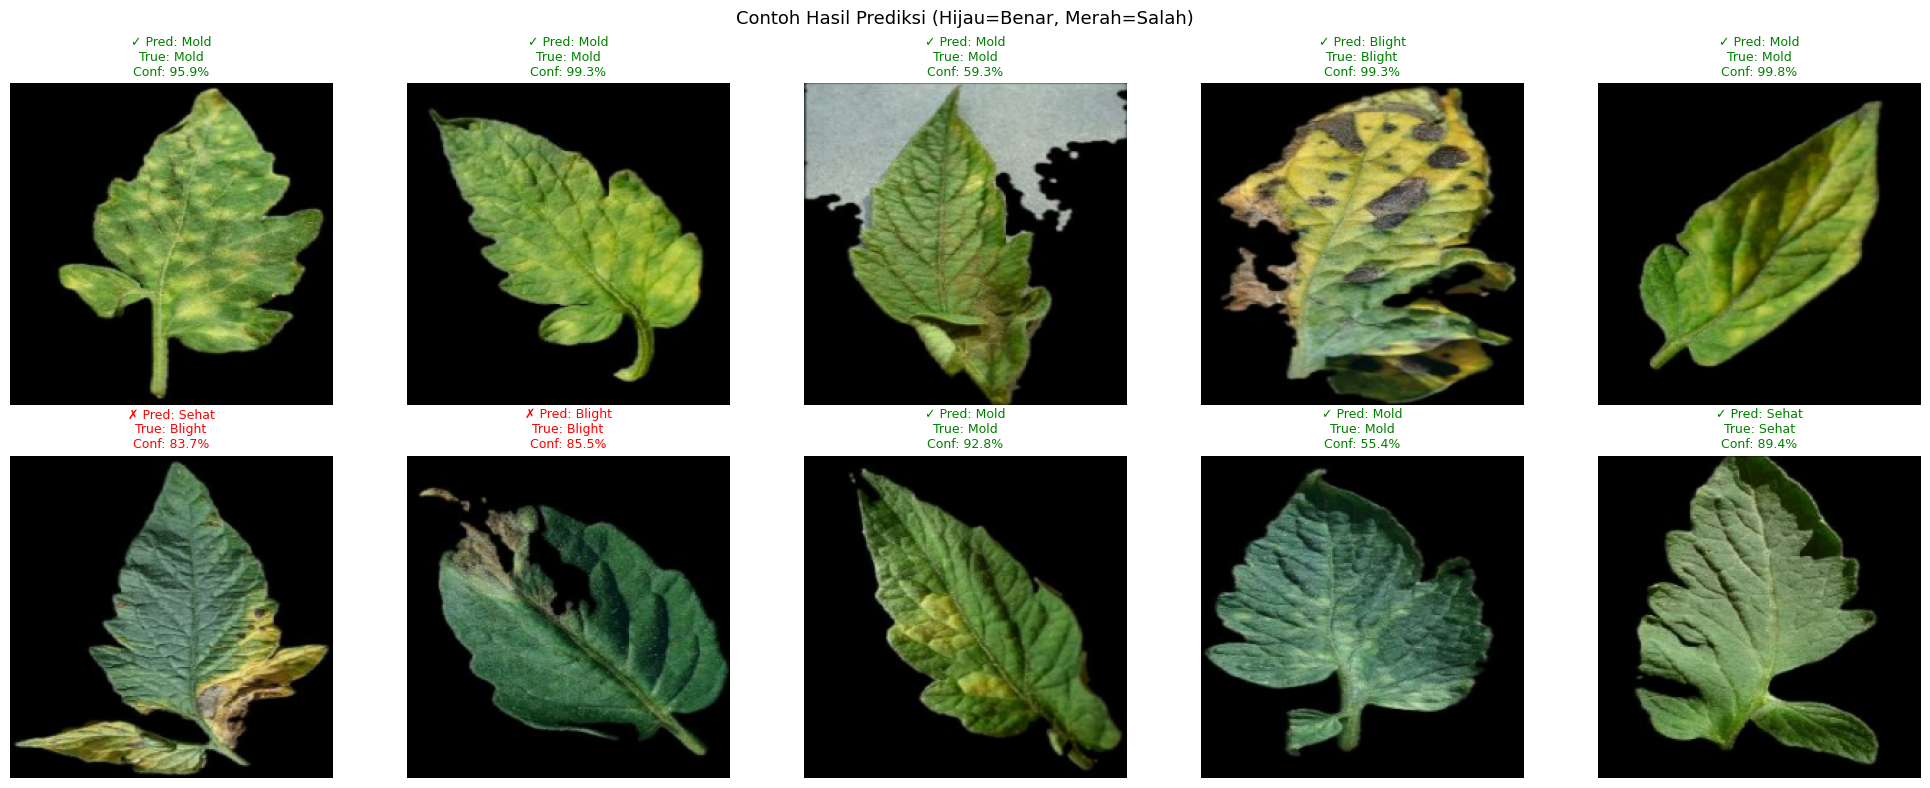

In [12]:
print("=== Contoh Prediksi Model ===\n")

plt.figure(figsize=(20, 8))
sample_count = 0

for images, labels in val_ds.take(1):
    preds = model.predict(images, verbose=0)

    for i in range(min(10, len(images))):
        true_idx  = labels[i].numpy()
        pred_idx  = np.argmax(preds[i])
        confidence = preds[i][pred_idx] * 100

        is_correct = true_idx == pred_idx

        ax = plt.subplot(2, 5, sample_count + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis('off')

        color = 'green' if is_correct else 'red'
        marker = '✓' if is_correct else '✗'

        plt.title(
            f"{marker} Pred: {class_names[pred_idx].split('_')[-1]}\n"
            f"True: {class_names[true_idx].split('_')[-1]}\n"
            f"Conf: {confidence:.1f}%",
            fontsize=9, color=color
        )

        sample_count += 1
        if sample_count >= 10:
            break

plt.suptitle('Contoh Hasil Prediksi (Hijau=Benar, Merah=Salah)', fontsize=13)
plt.tight_layout()
plt.savefig('prediction_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
from google.colab import files

def predict_leaf(image_path, threshold=0.5):
    """Prediksi kondisi daun dari gambar"""
    img = tf.keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.expand_dims(tf.keras.utils.img_to_array(img), 0)
    pred = model.predict(img_array, verbose=0)[0]

    confidence    = float(np.max(pred))
    predicted_cls = class_names[np.argmax(pred)]

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')

    if confidence >= threshold:
        color = 'green' if 'sehat' in predicted_cls.lower() or \
                           'healthy' in predicted_cls.lower() else 'red'
        plt.title(
            f"Hasil: {predicted_cls}\nConfidence: {confidence*100:.1f}%",
            fontsize=12, color=color
        )
    else:
        plt.title(
            f"Tidak yakin\nConfidence: {confidence*100:.1f}%",
            fontsize=12, color='gray'
        )
    plt.show()

    print(f"\n📊 Detail prediksi:")
    top = np.argsort(pred)[::-1]
    for idx in top:
        bar = '█' * int(pred[idx] * 30)
        print(f"  {class_names[idx]:<30s}: {pred[idx]*100:5.1f}% {bar}")

    return predicted_cls, confidence

print("Upload foto daun tomat:")
print("💡 Bisa download dari Google Images 'tomato leaf disease'")
print()
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\n{'='*60}")
    print(f"📷 {filename}")
    print("="*60)
    predict_leaf(filename)

Upload foto daun tomat:
💡 Bisa download dari Google Images 'tomato leaf disease'



In [14]:
model.save('model_plantvillage.keras')

with open('class_names.json', 'w') as f:
    json.dump(class_names, f, ensure_ascii=False)

print("=== File Hasil ===")
for f in ['model_plantvillage.keras', 'training_history.png',
          'confusion_matrix.png', 'sample_dataset.png',
          'prediction_samples.png', 'class_names.json']:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"  ✓ {f:<40s} ({size:.0f} KB)")

from google.colab import files
files.download('model_plantvillage.keras')
files.download('class_names.json')

=== File Hasil ===
  ✓ model_plantvillage.keras                 (11343 KB)
  ✓ training_history.png                     (83 KB)
  ✓ confusion_matrix.png                     (85 KB)
  ✓ sample_dataset.png                       (3933 KB)
  ✓ prediction_samples.png                   (1813 KB)
  ✓ class_names.json                         (0 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

interp = tf.lite.Interpreter(model_path='model.tflite')
interp.allocate_tensors()
print("OK, input:", interp.get_input_details()[0]['shape'])

from google.colab import files
files.download('model.tflite')

Saved artifact at '/tmp/tmp88zurhew'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132537589308816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132532896545488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132532896546256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132532896546448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132532896546064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132532840268624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132532840269968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132532840270928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132532840270544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132532840269008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1325328402

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
print("=" * 60)
print("📋 RINGKASAN UNTUK LAPORAN")
print("=" * 60)

final_loss, final_acc = model.evaluate(val_ds, verbose=0)

print(f"""
DATASET
  Nama         : PlantVillage Dataset
  Sumber       : Kaggle (abdallahalidev/plantvillage-dataset)
  Jumlah kelas : {num_classes}
  Kelas        : {', '.join(class_names)}
  Total gambar : {train_size + val_size}
  Split        : 80% training / 20% validation

ARSITEKTUR
  Base model   : MobileNetV2 (pre-trained ImageNet)
  Pendekatan   : Transfer Learning
  Input size   : {IMG_SIZE}x{IMG_SIZE} pixel
  Augmentasi   : Flip, Rotasi, Zoom, Translasi

TRAINING
  Optimizer    : Adam (lr=0.001)
  Loss         : Sparse Categorical Crossentropy
  Epochs       : {len(history.history['accuracy'])} (early stopping)
  Batch size   : {BATCH_SIZE}

HASIL
  Val Accuracy : {final_acc*100:.2f}%
  Val Loss     : {final_loss:.4f}
  Best Accuracy: {max(history.history['val_accuracy'])*100:.2f}%
""")

📋 RINGKASAN UNTUK LAPORAN

DATASET
  Nama         : PlantVillage Dataset
  Sumber       : Kaggle (abdallahalidev/plantvillage-dataset)
  Jumlah kelas : 5
  Kelas        : Tomat_Bacterial_Spot, Tomat_Early_Blight, Tomat_Late_Blight, Tomat_Leaf_Mold, Tomat_Sehat
  Total gambar : 4760
  Split        : 80% training / 20% validation

ARSITEKTUR
  Base model   : MobileNetV2 (pre-trained ImageNet)
  Pendekatan   : Transfer Learning
  Input size   : 224x224 pixel
  Augmentasi   : Flip, Rotasi, Zoom, Translasi

TRAINING
  Optimizer    : Adam (lr=0.001)
  Loss         : Sparse Categorical Crossentropy
  Epochs       : 15 (early stopping)
  Batch size   : 32

HASIL
  Val Accuracy : 91.18%
  Val Loss     : 0.2641
  Best Accuracy: 91.18%



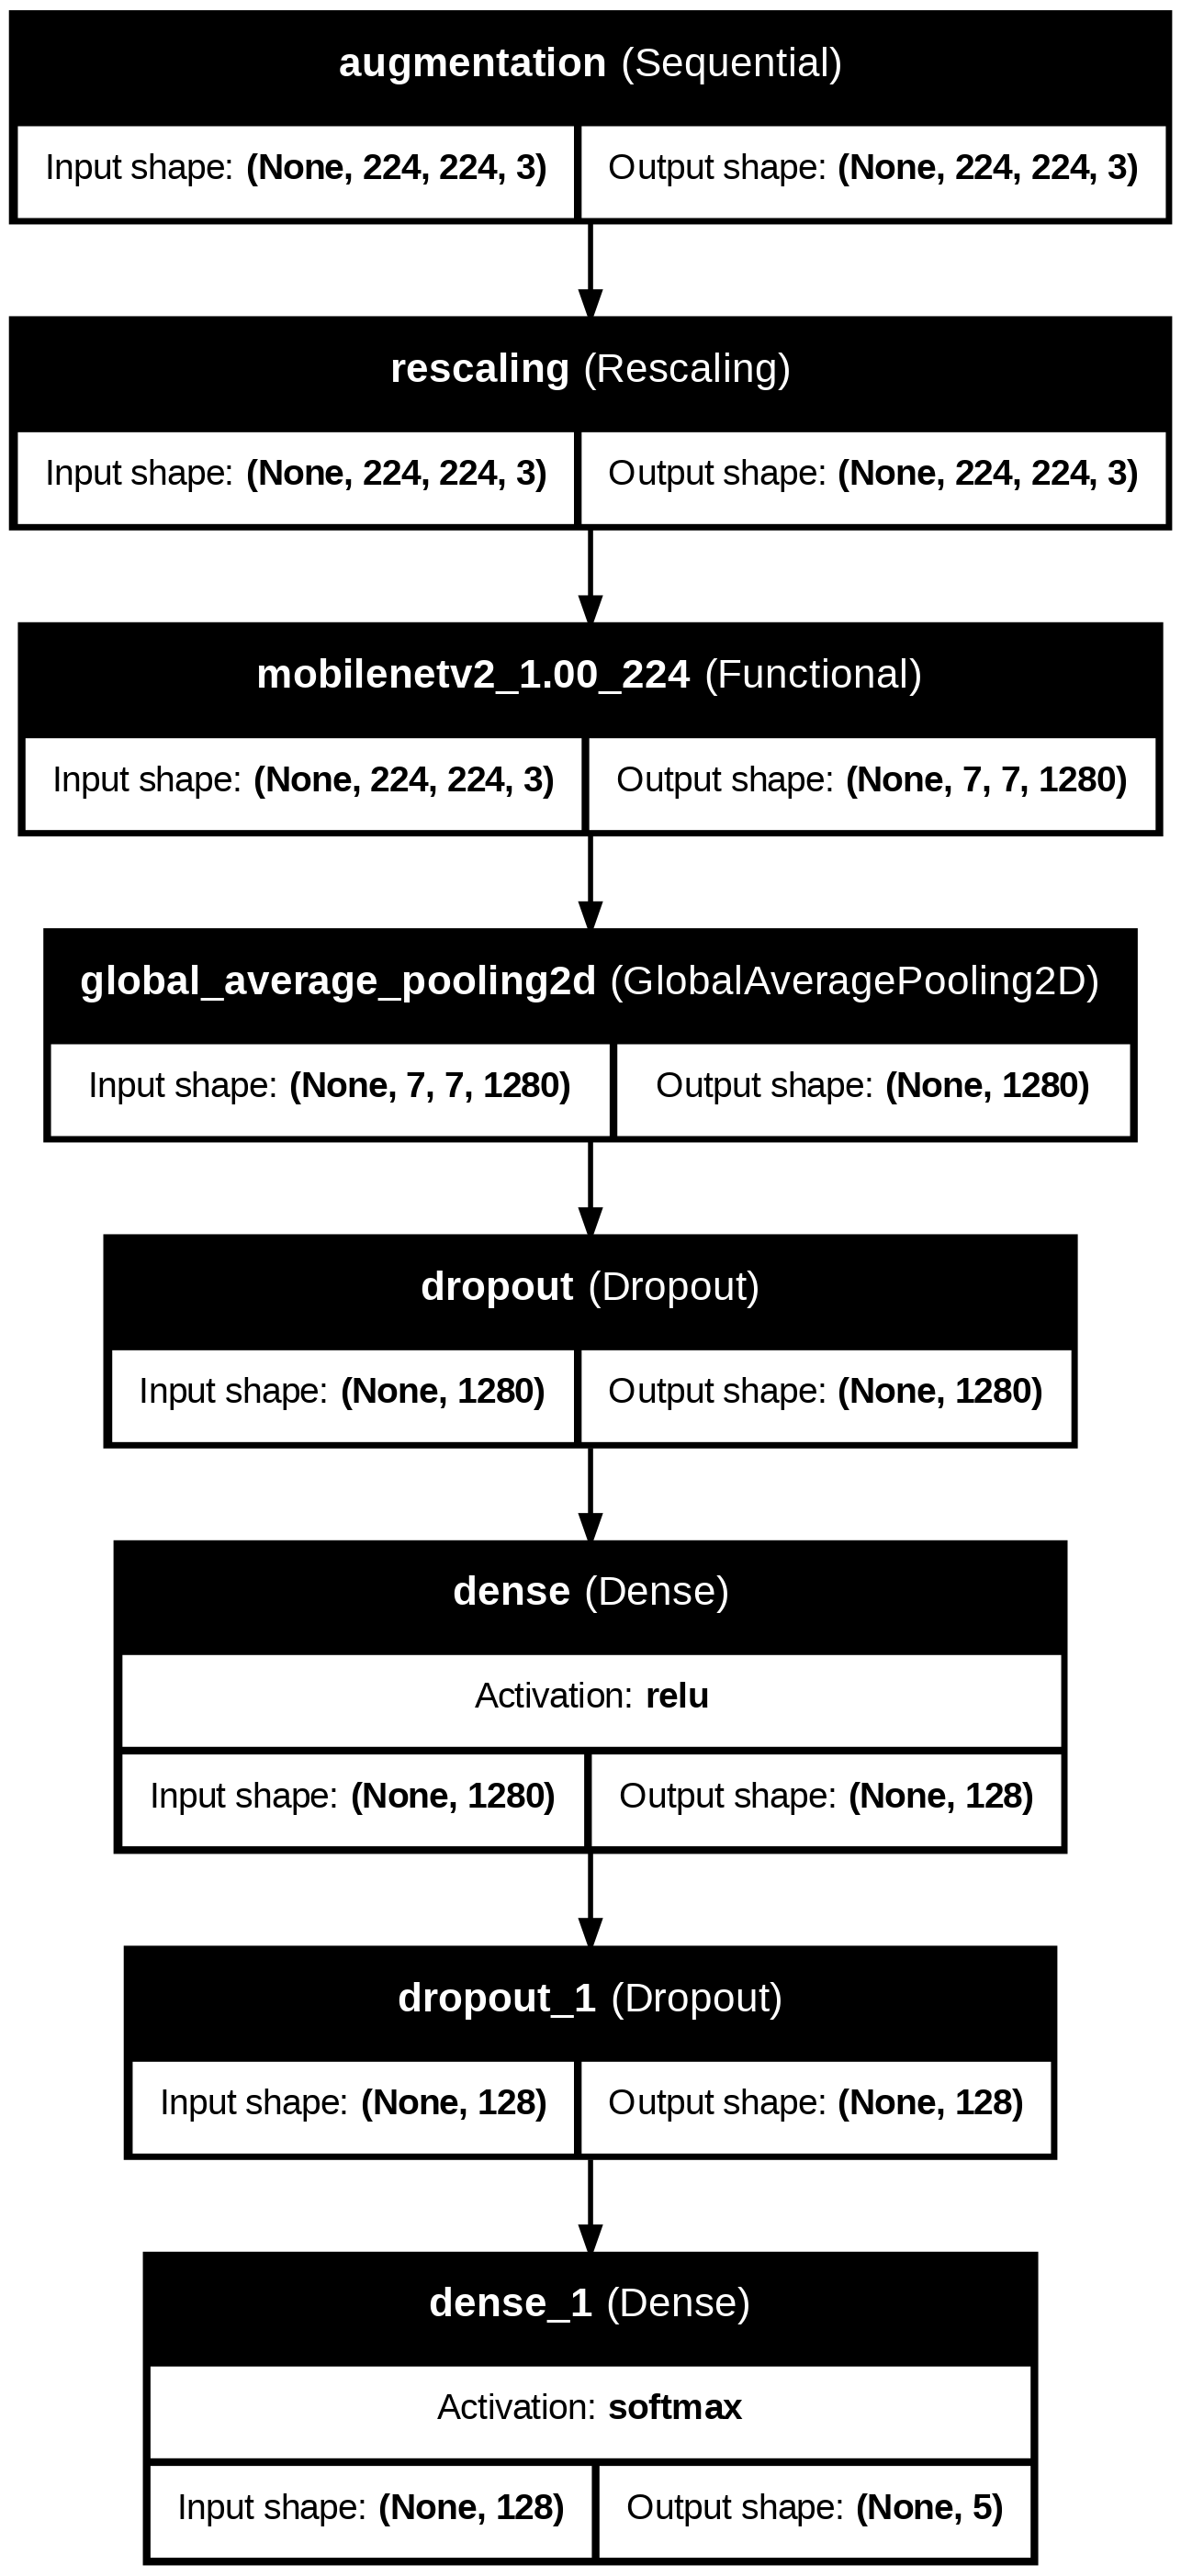

In [17]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file='arsitektur_model.png',
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
    dpi=200,
    rankdir='TB'
)

from IPython.display import Image
Image('arsitektur_model.png')